# New PLM generation drawing site from entropy

In [64]:
import numpy as np
import torch
import os, platform
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
from seq_utils import read_tensor_from_txt, set_seed


In [55]:
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from model_PCA_cond import ModelPCAcondJ
from dcascore import *
from utils import quickread
from attention import trainer, trainerCondJ, trainer_PCA_comp_2_model, ar_trainer # choose trainer


# back to original path (in PLM)
sys.path.pop(0)  # Removes the parent_dir from sys.path

'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src'

## Load Q,K,V

In [56]:
"""
    Load Q, K, V matrices from jdoms (after training)
"""
set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
nb_PCA_comp=2
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]

model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)

i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
# Mask only part without CPA
H, _, M = K_1.shape #(M=N+m)

#W[:,:,:-2] = W[:,:,:-2] * mask
W = W * mask

    
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)

torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [57]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37202728570888266
Computed theta: 0.3268577458459699


100%|██████████| 14502/14502 [00:13<00:00, 1053.91it/s]

3265.70225762244


In [58]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

(21, 63)
(63,)


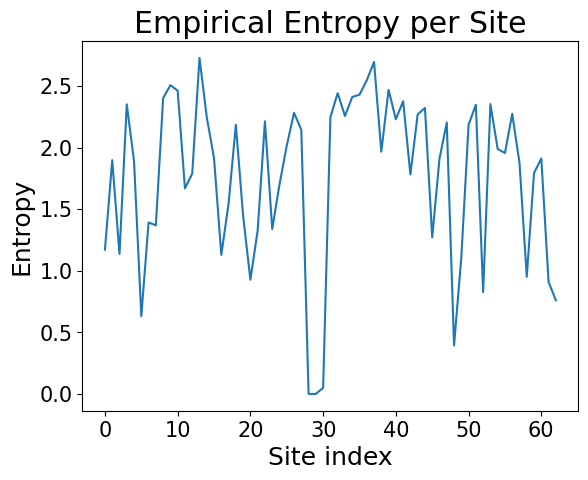

In [59]:
f_emp = compute_empirical_freqs(Z, W, q)
print(f_emp.shape)
probas = f_emp / f_emp.sum(axis=0, keepdims=True)
entropy = -np.sum(probas * np.log(probas + 1e-10), axis=0)  # Adding a small constant to avoid log(0)
print(entropy.shape)
plt.plot(entropy)
plt.xlabel('Site index')
plt.ylabel('Entropy')
plt.title('Empirical Entropy per Site')
plt.show()  

In [66]:
def site_probas(S, beta=1.0):
    """
    Compute site probabilities with temperature scaling.
    S : ndarray of shape (q, N) with empirical frequencies
    beta : inverse temperature
    Returns: ndarray of shape (q, N) with probabilities
    """
    p = np.exp(beta*S)
    probas = p / p.sum(axis=0, keepdims=True)
    return probas

p = site_probas(entropy, beta=1.0)

def beta_tanh(N_iter, N_tot, a=1):
    # calculate beta as tanh of iteration ratio
    ratio = N_iter / N_tot
    # shift so that tanh goes from -1 to 1
    #print(a*(ratio-0.5))
    beta = np.tanh(a*(ratio-0.5))  # scale factor to adjust steepness
    return beta

-49.5


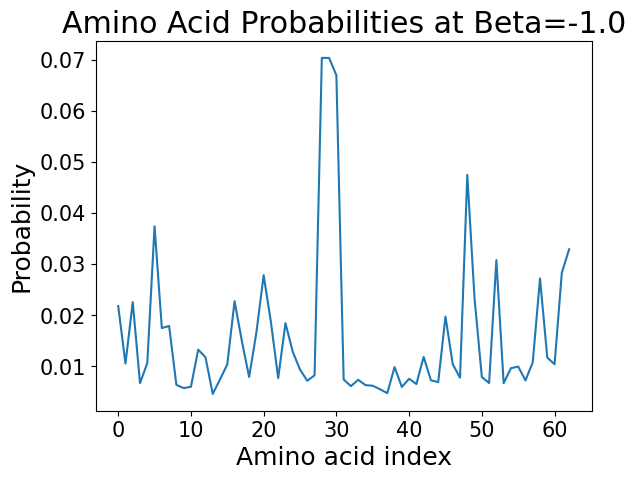

In [61]:
# test plot probas
beta = beta_tanh(1, 200, a=100)
p_test = site_probas(entropy, beta=beta)
# plot p_test for all sites
plt.plot(p_test)
plt.xlabel('Amino acid index')
plt.ylabel('Probability')
plt.title('Amino Acid Probabilities at Beta={}'.format(beta))
plt.show()

In [62]:
def generate_plm_vec(J, N_seqs=40000, init_sequence=None, beta=1, nb_PCA_comp=0, beta_pca = 0, target_coords=np.array([]), site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta, nb_PCA_comp=nb_PCA_comp, target_coords=target_coords, beta_PCA=beta_pca)

    for i in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:
            beta = beta_tanh(i, N_seqs, a=100)
            probas = site_probas(entropy, beta=beta)
            site = np.random.choice(seq.L, p=probas)  # weighted random
            #print("Selected site:", site)
            site = int(site)
        #seq.check_vectorized(site)
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())

    return np.array(gen_sequences)

In [31]:
class SequencePLMvec:
    def __init__(self, J, initial_sequence = None, beta = 1, nb_PCA_comp=0,target_coords=np.array([]),J_tens_PCA=None,beta_PCA=1):
        """
        Initialize the SequencePLM object with a coupling tensor J of the family and an optional initial sequence.
        """
        self.J = J
        self.J_PCA=J_tens_PCA
        #self.L = J.shape[-1]
        self.beta = beta
        self.beta_PCA=beta_PCA
        self.nb_PCA_comp=nb_PCA_comp
        if not (J_tens_PCA is None):
            if nb_PCA_comp!=J_tens_PCA.shape[-1]:
                print("Mismatch of PCA tensor and nb PCA components indicated")
        if J_tens_PCA is None:
            self.L = J.shape[-1] - nb_PCA_comp  # Length of the sequence without PCA components
        else:
            self.L = J.shape[-1]
        if initial_sequence is None:
            self.sequence = np.random.choice(np.arange(21), self.L) # Sequence of ints (1 to 21) 
            if len(target_coords)==nb_PCA_comp:
                self.sequence = np.concatenate((self.sequence,target_coords))
            else:
                print("number of PCA components doesn't match size of PCA list")
        else:
            self.sequence = initial_sequence

    def to_letter(self):
        """
        Show sequence as letters
        """
        print("Sequence:", self.sequence)
        num_to_letter = {v: k for k, v in letter_to_num.items()}
        letter_seq = ''.join([num_to_letter[i] for i in self.sequence[:len(self.sequence)-self.nb_PCA_comp]])
        print(letter_seq)
        return letter_seq

    def plm_calc(self, site, trial_aa):
        """
        Compute unnormalized pseudo-likelihood of trial_aa at a given site.
        site: int from 0 to L-1
        trial_aa: int from 0 to 21 (amino acid index)
        """
        if site < 0 or site >= self.L:
            raise ValueError(f"Site {site} is out of bounds for sequence length {self.L}.")
        sum_energy = 0.0
        if not ( self.J_PCA is None):      
            for i in range(self.nb_PCA_comp):
                    PCA_coord = self.sequence[self.L + i] 
                    sum_energy += self.beta_PCA * self.J_PCA[trial_aa, PCA_coord, site, i] # J_PCA of shape ([q, Nbins, L, nb_PCA_comp])
        else:
            for i in range(self.nb_PCA_comp):
                sum_energy+=self.beta_PCA*self.J[trial_aa,self.sequence[self.L+i],site,self.L+i] # J of shape ([q, q+Nbins, L, L+nb_PCA_comp])
        for j in range(self.L):
            if j == site:
                continue
            aa_j = self.sequence[j]
            sum_energy += self.beta * self.J[trial_aa, aa_j, site, j] 
        prob = sum_energy  
        return prob
    
    def plm_calc_vec(self, site):
        """
        Compute unnormalized pseudo-likelihoods for ALL trial amino acids at once.
        Returns array of shape (q,) with one score per amino acid.
        """
        q = 21
        # trial amino acids (0 to 20) (ints)
        trial_aas = np.arange(q)[:, None]  # (21,1)
        # --- Sequence couplings ---
        mask = np.arange(self.L) != site
        other_sites = np.arange(self.L)[mask]
        aa_vector = self.sequence[:self.L][mask]              # amino acids at other sites
        aa_vector = aa_vector.astype(int)
        #print("Site:", site)
        #print("Other sites:", other_sites)
        #print("AA vector:", aa_vector)
        #print("Trial AAs:", trial_aas)
        seq_energies = self.J[trial_aas, aa_vector, site, other_sites]  # (21, L-1)
        sum_energy = self.beta * np.sum(seq_energies, axis=1)           # (21,)

        # --- PCA couplings ---
        if self.nb_PCA_comp > 0:
            pca_indices = np.arange(self.L, self.L + self.nb_PCA_comp)  # j-axis indices
            pca_bins = self.sequence[pca_indices]                       # PCA bins

            if self.J_PCA is not None:
                # J_PCA: (q, Nbins, L, nb_PCA_comp)
                pca_energies = self.J_PCA[trial_aas, pca_bins, site, np.arange(self.nb_PCA_comp)]
            else:
                # J: (q, q+Nbins, L, L+nb_PCA_comp) — bins already shifted by q
                pca_energies = self.J[trial_aas, pca_bins, site, pca_indices]

            sum_energy += self.beta_PCA * np.sum(pca_energies, axis=1)

        return sum_energy
    
    def plm_site_distribution(self, site):
        """
        Compute probability distriution for specific site (normalized)
        """
        probs = []
        for trial_aa in range(21):
            probs.append(self.plm_calc(site, trial_aa))
        probs = np.array(probs)
        probs = np.exp(probs-probs.max()) #to avoid overflow for high beta
        probs /= probs.sum()
        return probs
    
    def plm_site_distribution_vec(self, site):
        """
        Compute probability distribution for specific site (normalized).
        """
        sum_energy = self.plm_calc_vec(site)  # (21,)
        probs = np.exp(sum_energy - np.max(sum_energy))  # stable softmax
        probs /= probs.sum()
        return probs
    def check_vectorized(self, site):
        """
        Check that vectorized and loop implementations give same result
        """
        probs_loop = self.plm_site_distribution(site)
        probs_vec = self.plm_site_distribution_vec(site)
        assert np.allclose(probs_loop, probs_vec), f"Mismatch at site {site}"
        print(f"Vectorized check passed at site {site}")

    def draw_aa(self, site, vec=True):
        """
        Sample a new AA at the given site from PLM distribution
        """
        if vec:
            probs = self.plm_site_distribution_vec(site)
        else:
            probs = self.plm_site_distribution(site)
        new_aa = np.random.choice(21, p=probs) # aa from 0 to 20
        new_aa = int(new_aa)
        self.sequence[site] = new_aa
    
    def seq_energy(self):
        sum=0
        for i in range(self.L):
            for j in range(self.L):
                sum+=self.J[self.sequence[i], self.sequence[j],i,j]
        return sum

In [78]:
#from plm_model import SequencePLMvec
generated_seqs = generate_plm_vec(Jtens.cpu().numpy(), N_seqs=500000, beta=1, site_selector=0)

100%|██████████| 500000/500000 [01:38<00:00, 5060.82it/s]


In [77]:
generated_seqs__entropy500 = generated_seqs.copy()

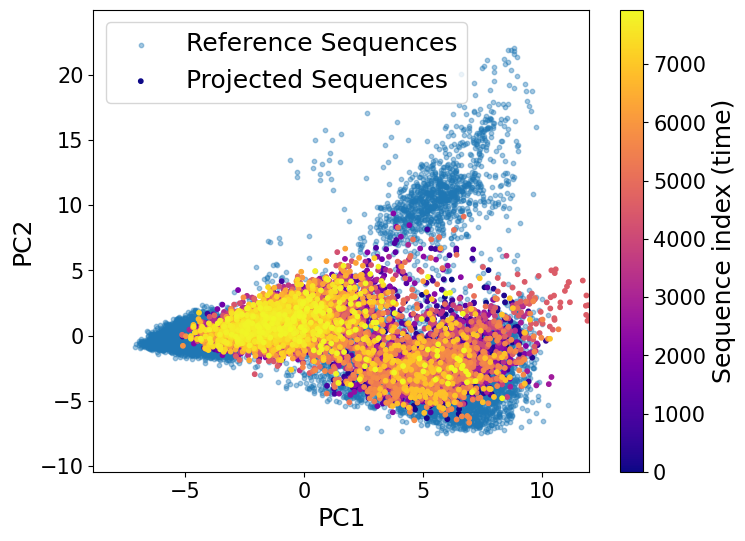

In [79]:
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
plot_projected_pca_time(Z.T,np.array(generated_seqs[::63], dtype=int))

(21, 63)
(21, 63)


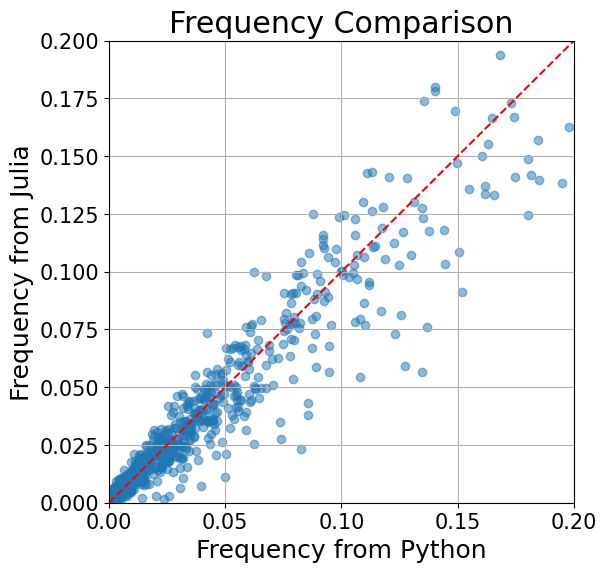

In [80]:
f_train = compute_empirical_freqs(Z, W, q=21)
f_train_flat = f_train.flatten()
print(f_train.shape)

f_gen = compute_empirical_freqs(np.array(generated_seqs.T, dtype=int), None, q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_train_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

In [50]:
from hamming_dist import hamming_dist, energy_corr_array
initial_sequence = np.array(generated_seqs[0], dtype=int)
hamming_distances = []
for seq in np.array(generated_seqs,dtype=int):
    distance = hamming_dist(initial_sequence, seq)
    hamming_distances.append(distance)
hamming_distances = np.array(hamming_distances)
correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))

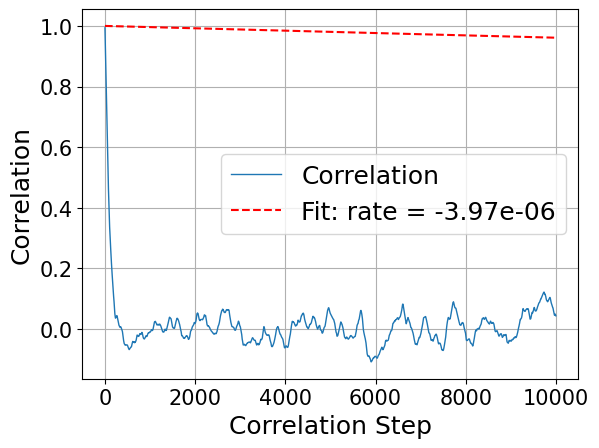

In [51]:

from scipy.stats import linregress
 
def plot_decorrelation(correlation,range,save_path=None):
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = correlation[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, np.exp(y_vals))
    
    # Store the slope for this beta
    
    
    # Plot the correlation curve and linear fit
    plt.plot(correlation, marker='', linestyle='-', linewidth=1, label="Correlation")
    plt.plot(np.arange(len(correlation)), np.exp(slope * np.arange(len(correlation))), color='r',linestyle="--", label=f"Fit: rate = {slope:.2e}")
    plt.xlabel("Correlation Step")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(save_path)
    plt.show()
    
plot_decorrelation(correlation, int(len(hamming_distances)/5), save_path=None)